In [15]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.212"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_sg_int4_v2 - envelope memory 16384 samples (38.095 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 3

In [3]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12\2020525'

# Connect yoko

In [23]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91T810992'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)

True

In [36]:
Yoko_current = 2.47 # [mA]
yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=20e-6)

5.6e-05

# System config

In [6]:
r1 = 5352.79
r2 = 5494.19
r3 = 5667.69
r4 = 5796.46
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]
res_mixer = round(np.sum(r)/6)
res_mixer=5800
q1, q2, q3, q4, q5, q6 = [2, 0, 1, 7, 0, 14]
q = [q1, q2, q3, q4, q5, q6]

In [7]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': r,
          'mixer_freq': res_mixer,
          'res_gains': [0.5]*6,
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 2,
          'ro_len': 2,
          'relax_delay':50
         }

qb_cfg={
    'qb_ch':q,
    'f_q': 4200,
    'qmixer_freq': 4200,
    'q_len':5,
    'q_gain': 0.01,
    'sigma': 0.5,
}

config = {**config, **qb_cfg}

# Time of Flight

  0%|          | 0/1000 [00:00<?, ?it/s]

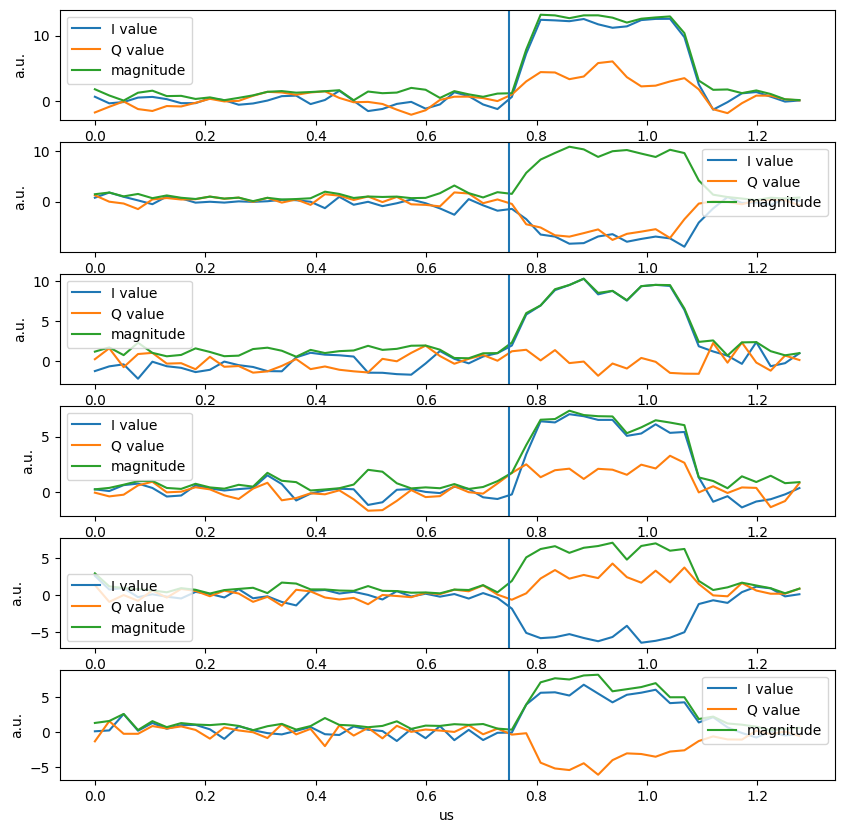

In [8]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':1.3, 
    'res_gains': [1.0]*6, 
    'res_freqs':np.array(r)-15, 
    'trig_time': 0}) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, soft_avgs=1000)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# for i, ch in enumerate(config['ro_chs']):
#     # frequency-matching cross-check
#     f_gen = prog.res_chs[config['res_ch']]['mux_tones'][i]['freq_rounded']
#     f_ro = prog.ro_chs[ch]['ro_config']['f_rounded']
#     print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

# Mux OneTone

In [9]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [10]:
n_roch = 6
F_Span = 20
F_Steps = 81

sweep = np.linspace(-F_Span, F_Span, F_Steps)
z_list = [[] for _ in range(6)]  
config['res_gains'] = [0.5] * n_roch

for i in tqdm(sweep):
    config['res_freqs'] = np.array(r) + i
    prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=config)
    results = prog.acquire(soc, soft_avgs=10, progress=False)
    
    for idx, res in enumerate(results):
        z_list[idx].append(res[0][0] + 1j * res[0][1])

100%|██████████| 81/81 [00:12<00:00,  6.54it/s]


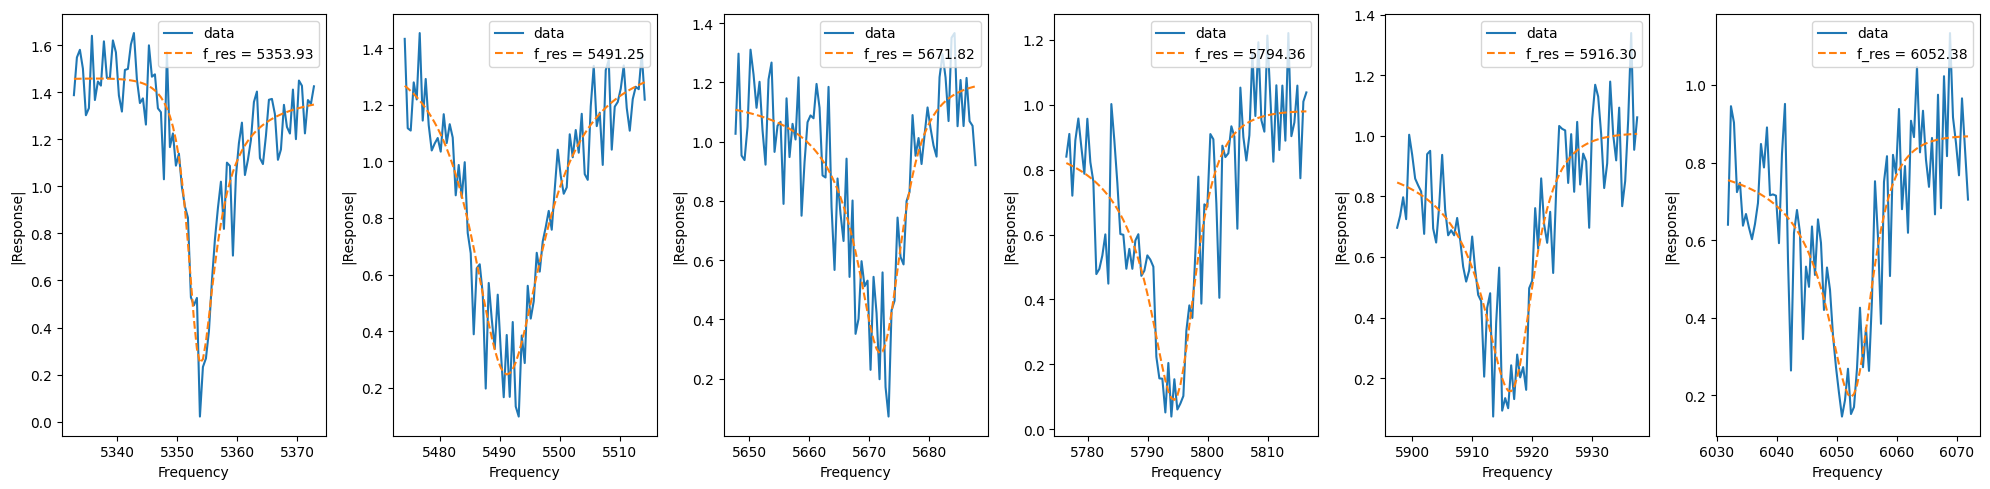

In [11]:
popt = [[] for _ in range(n_roch)]
fit_res = [[]] * n_roch


fig, ax = plt.subplots(1, n_roch, figsize=(20,5))

for i in range(n_roch):
    freq_sweep = r[i] + sweep
    mag_response = np.abs(z_list[i])

    ax[i].plot(freq_sweep, mag_response, label='data')
    popt[i], _ = fit_asym_lor(freq_sweep, mag_response)
    ax[i].plot(freq_sweep, asym_lorfunc(freq_sweep, *popt[i]), '--', label=f'f_res = {popt[i][2]:.2f}')
    ax[i].legend(loc='upper right')
    ax[i].set_xlabel('Frequency')
    ax[i].set_ylabel('|Response|')
    fit_res[i] = round(popt[i][2], 2)

plt.tight_layout()
plt.show()

In [ ]:
data_path = data_path

for idx in range(n_roch):
        exp_name = f"res onetone mux r{idx}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + sweep)*1e6},  

                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(x[idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Punchout

In [16]:
class MuxPunchout(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0, 1, 2, 3, 4, 5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)


In [19]:
n_roch=6
F_Sapn = 20
F_Steps = 61

G_Start = 0.05
G_Stop = 1
G_Steps = 81
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
gain = np.linspace(G_Start, G_Stop, G_Steps)  


z = [] 
for g in tqdm(outer_loop, desc="Gain Sweep"):
    config['res_gains'] = [g] * n_roch
    amps = []  
    for f in tqdm(fpts, desc="Freq Sweep", leave=False):
        config['res_freqs'] = np.array(r) + f
        prog = MuxPunchout(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)
    z.append(np.array(amps))
z = np.array(z)  


Gain Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

...

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/61 [00:00<?, ?it/s]

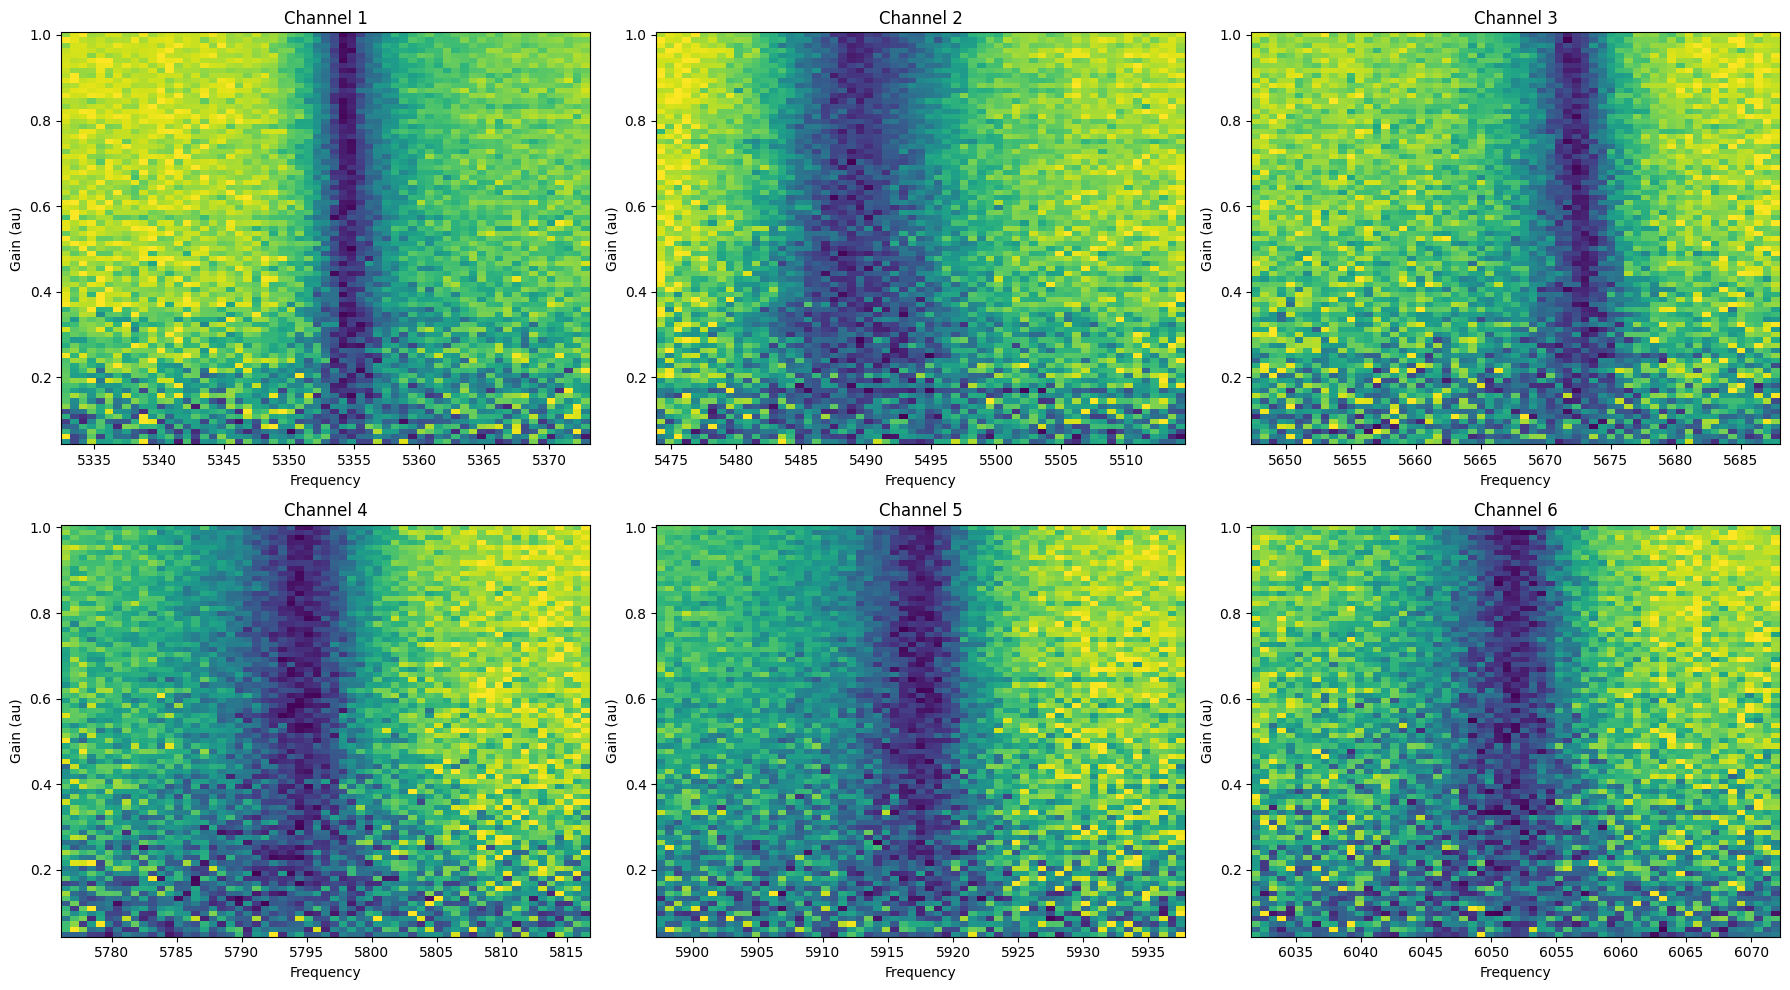

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    data = np.abs(z[:, :, idx]) 
    norm_data = np.zeros_like(data)
    for i in range(data.shape[0]):  
        max_val = np.max(data[i])
        if max_val != 0:
            norm_data[i] = data[i] / max_val  
        else:
            norm_data[i] = data[i]  
    pcm = axes[idx].pcolormesh(r[idx] + fpts, gain, norm_data, shading='auto')
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()

In [172]:
data_path = data_path

for idx in range(6):
        exp_name = f"res pdr mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + fpts)*1e6},  
                y_info={'name': 'DAC Gain', 'unit': "a.u",
                        'values': gain},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Flux

In [25]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [31]:
n_roch = 6

F_Sapn = 15
F_Steps = 61

Curr_Start = -5
Curr_Stop = 5
Curr_Step = 601
config['res_gains'] = [0.3] * n_roch
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
flux = np.linspace(Curr_Start, Curr_Stop, Curr_Step)

z = []

for curr in tqdm(flux, desc="Flux Sweep"):
    yoko_global.setValue(sQuant='Current', value=curr* 1e-3, rate=10e-6)
    amp_per_flux = []

    for i in tqdm(sweep, desc="Freq Sweep", leave=False):
        config['res_freqs'] = np.array(r) + i
        prog = MuxOneTone(soccfg, reps=100, final_delay=0.1, cfg=config)
        results = prog.acquire(soc, soft_avgs=50, progress=False)

        amp_per_freq = []

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amp_per_flux.append(amp_per_freq)

    z.append(np.array(amp_per_flux))

z = np.array(z)

Flux Sweep:   0%|          | 0/601 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

...

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

Freq Sweep:   0%|          | 0/81 [00:00<?, ?it/s]

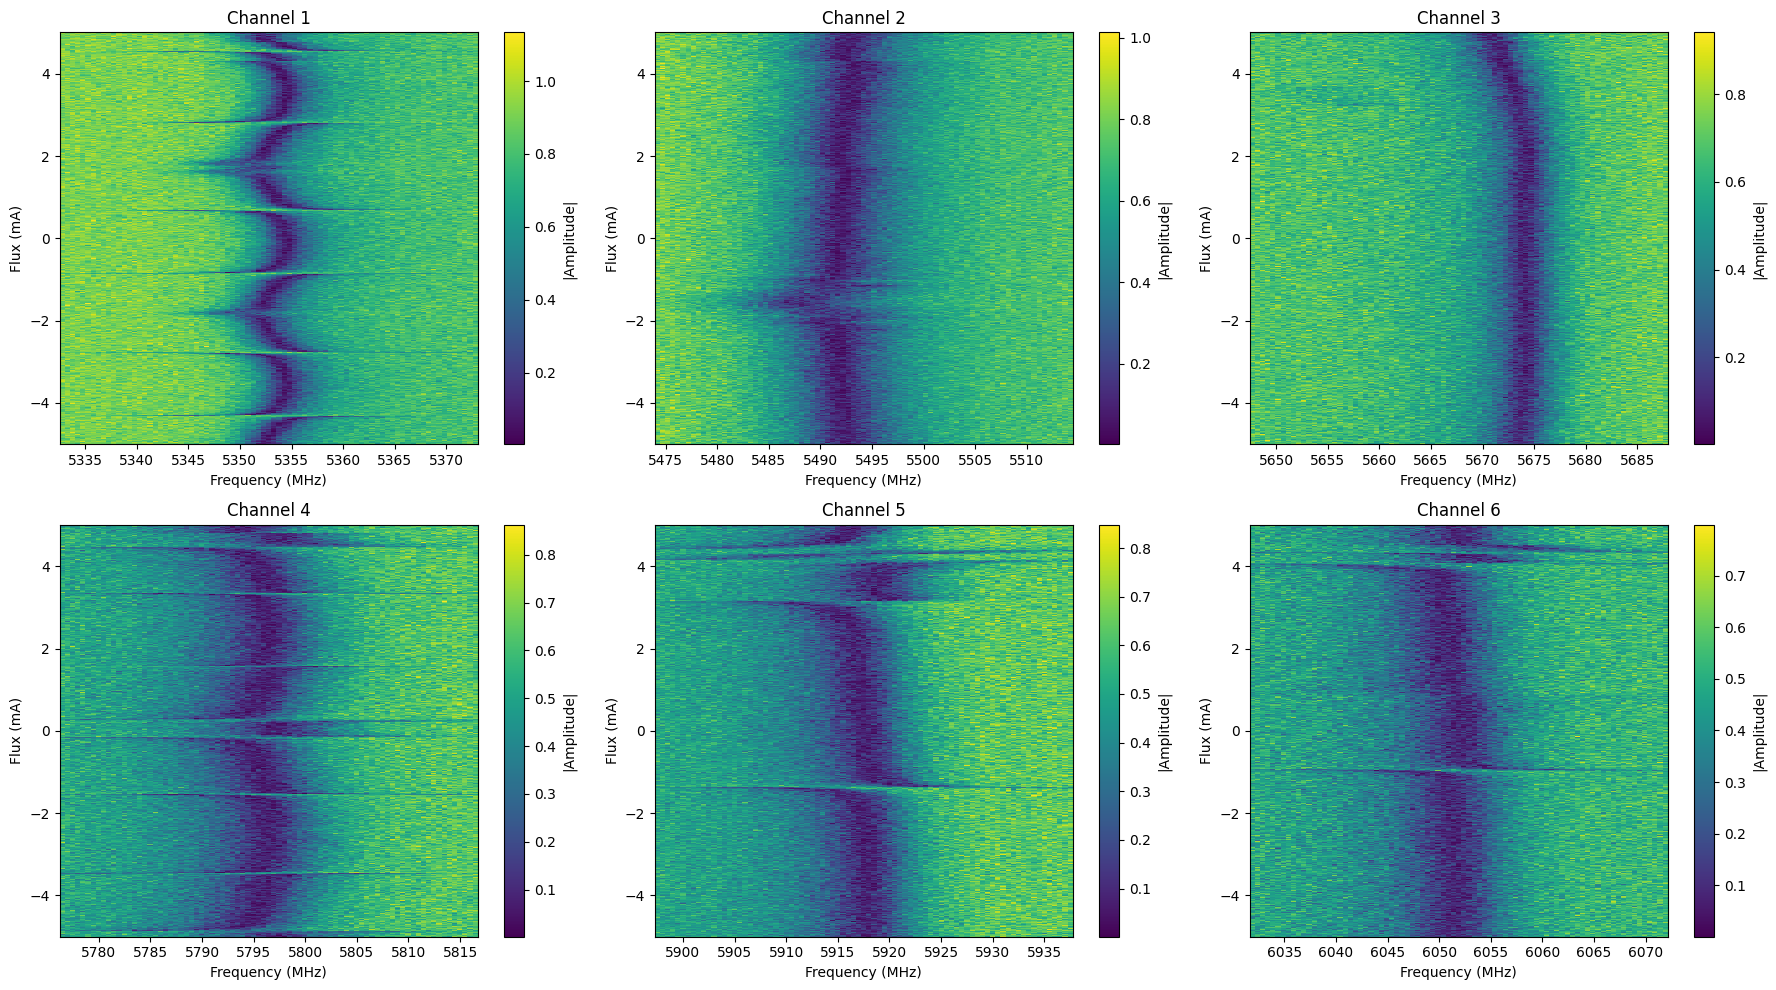

In [32]:
freqs = np.array(r)[:, None] + sweep[None, :]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    pcm = axes[idx].pcolormesh(
        freqs[idx], flux, 
        np.abs(z[:, :, idx]),
        shading='auto'
    )
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency (MHz)')
    axes[idx].set_ylabel('Flux (mA)')
    fig.colorbar(pcm, ax=axes[idx], label='|Amplitude|')

plt.tight_layout()
plt.show()


In [33]:
data_path = data_path

for idx in range(6):
        exp_name = f"res flux mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[idx])*1e6},  
                y_info={'name': 'yoko current', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Aiming One resonator

In [ ]:
class MuxOneToneFocus(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)

config = {'res_ch': 12,
          'ro_chs': [2],
          'pulse_freqs': r,
          'mixer_freq': 5750,
          'pulse_gains': [0.15],
          'pulse_phases': [0.0],
          'ro_phases': [0.0],
          'trig_time': 0.7,
          'pulse_len': 1.0,
          'ro_len': 1.2,
         }


100%|██████████| 51/51 [00:05<00:00,  9.53it/s]


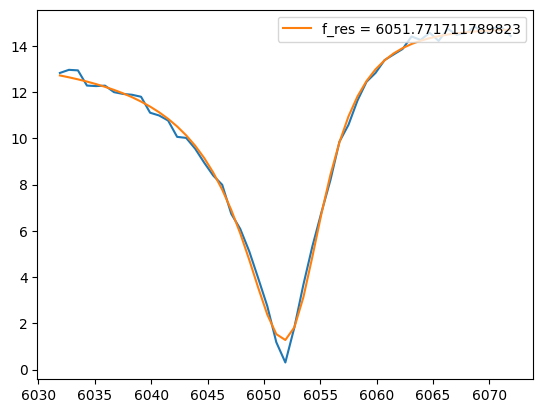

In [122]:
res_idx = 5

initial = [r[res_idx]]
sweep = np.linspace(-20, 20, 51)
z1=[]

config['pulse_gains'] = [0.15]
for i in tqdm(sweep):
    config['pulse_freqs'] = np.array(initial)+i
    prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.5, cfg=config)
    x1, = prog.acquire(soc, soft_avgs=10, progress=False)
    z1.append(x1[0][0]+1j*x1[0][1])

## Plot ##
plt.plot(initial + sweep, np.abs(z1))
popt,_ = fit_asym_lor(initial + sweep, np.abs(z1))
plt.plot(initial + sweep, asym_lorfunc(initial + sweep, *popt), label=f'f_res = {popt[2]}')
plt.legend(loc='upper right')
res_freq = round(popt[2], 2)

## Punch out

In [129]:
initial = [r[res_idx]]
sweep_f = np.linspace(-20, 20, 41)  # freq sweep points
sweep_g = np.linspace(0.02, 1, 20)  # gain sweep points


z = [] 

outer_loop = tqdm(sweep_g, desc="Gain Sweep")

for g in outer_loop:
    config['pulse_gains'] = [g] 
    amps = []  

    for f in (sweep_f):
        config['pulse_freqs'] = np.array(initial) + f

        prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)

    z.append(np.array(amps))

z = np.array(z)  # z.shape = (n_gain, n_freq, n_roch)


Gain Sweep: 100%|██████████| 20/20 [01:21<00:00,  4.06s/it]


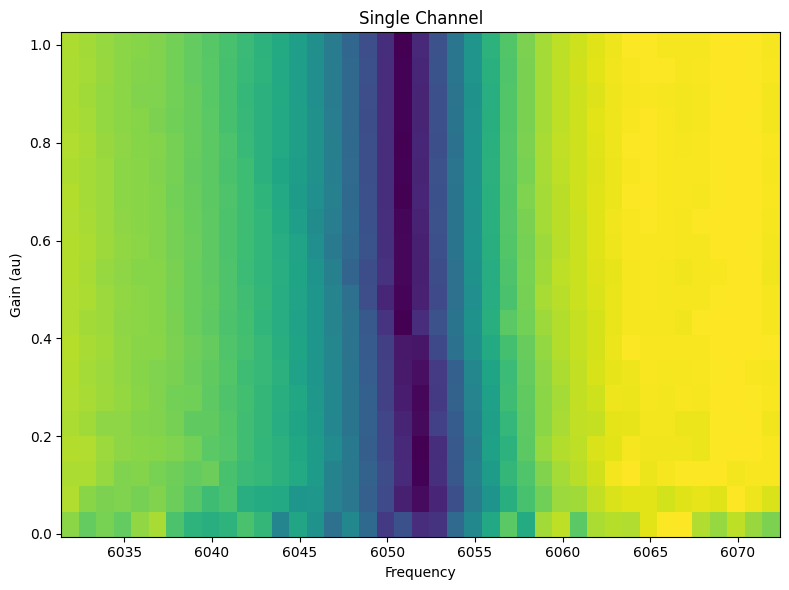

In [130]:
fpts = sweep_f
gain = sweep_g

fig, ax = plt.subplots(figsize=(8, 6))  


data = np.abs(z[:, :, 0]) 

norm_data = np.zeros_like(data)
for i in range(data.shape[0]):  
    max_val = np.max(data[i])
    if max_val != 0:
        norm_data[i] = data[i] / max_val  
    else:
        norm_data[i] = data[i]

pcm = ax.pcolormesh(np.array(initial) + sweep_f, sweep_g, norm_data, shading='auto')

ax.set_title('Single Channel')
ax.set_xlabel('Frequency')
ax.set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()


In [128]:
data_path = data_path
exp_name = f"res pdr R{res_idx+1}"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': fpts*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gain},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  z[:, :, 0]},
        comment=f'flux at half flux',
        tag='OneTone'
)

# Mux Two Tone

In [12]:
class MuxTwoTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("floop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            if i==0:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q1'], 
                            phase= 0,
                            gain=cfg['q_gain'][i],
                            length=cfg["q_len"],
                            )
            else:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'],                        
                            phase= 0,
                            gain=cfg['q_gain'][i],
                            length=cfg["q_len"],
                            )

    def _body(self, cfg):
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.02, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 2,
          'ro_len': 2,
         }

span = 200
step = 200

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': 4300 + QickSweep1D("floop", -span, span),
    'f_q1': 4600 + QickSweep1D("floop", -span, span),
    'qmixer_freq': 4300,
    'q_len':5,
    'q_gain': [0.4, 0, 0, 0.4, 0., 0.],
    'sigma':0.05
}

run_cfg = {**config, **qb_cfg}

In [13]:
prog = MuxTwoTone(soccfg, reps=100, final_delay=0.2, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=50)
freqs = [[]]*6
for idx in range(6):
    freqs[idx]= prog.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)


  0%|          | 0/50 [00:00<?, ?it/s]

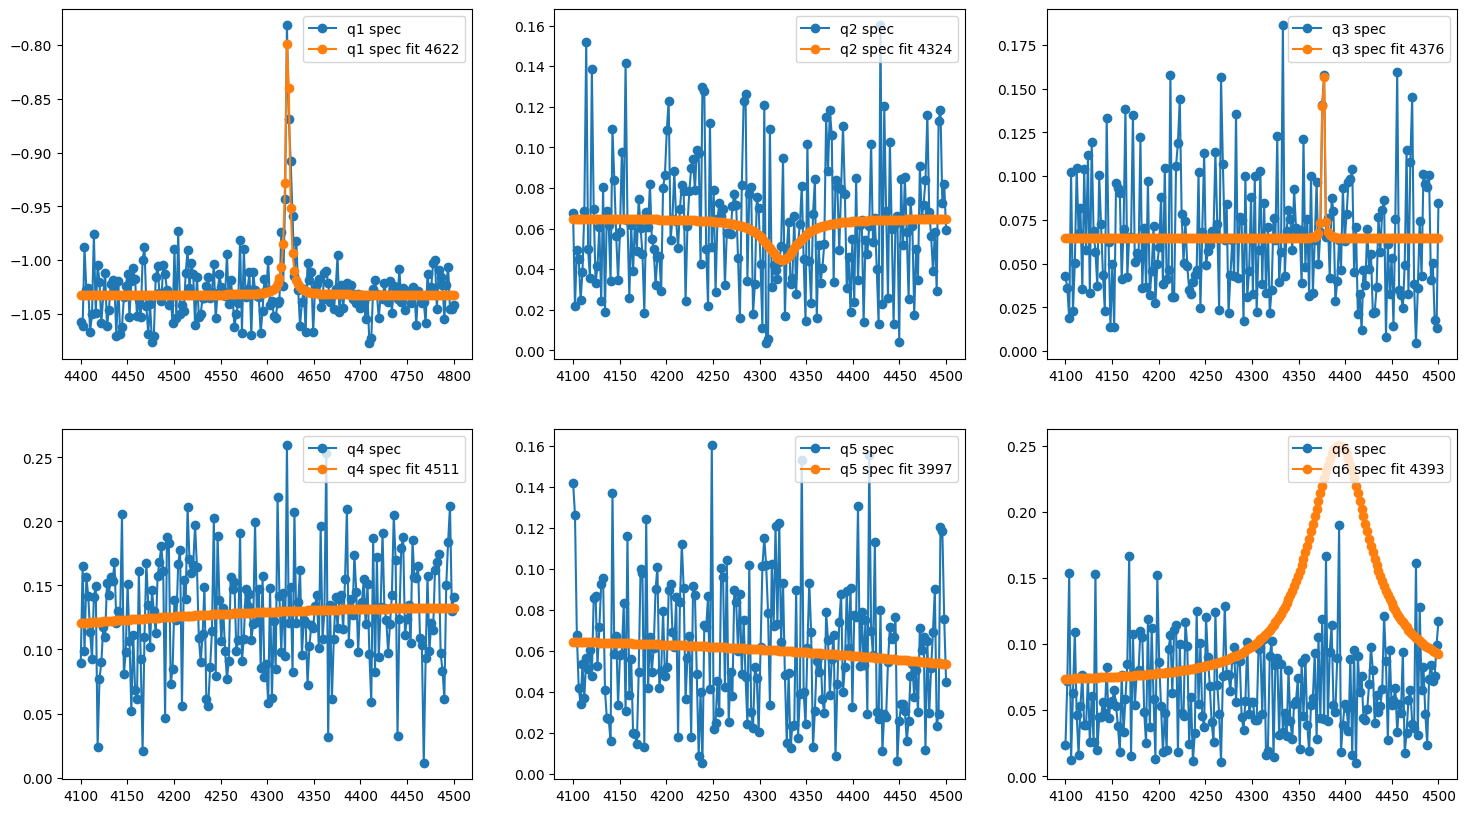

In [14]:
from data_fitting.fitting import lorfunc, fitlor
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
q_fit=[[]]*6
for i in range(6):
    if i ==0:
        axes[i].plot(freqs[i],np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} spec')
        q_fit[i], _ = fitlor(freqs[i],  np.angle(iq_list[i][0].dot([1,1j])))
        axes[i].plot(freqs[i], lorfunc(freqs[i], *q_fit[i]), marker='o', label = f'q{i+1} spec fit {q_fit[i][2]:.0f}')
    else:
        axes[i].plot(freqs[i],np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} spec')
        q_fit[i], _ = fitlor(freqs[i],  np.abs(iq_list[i][0].dot([1,1j])))
        axes[i].plot(freqs[i], lorfunc(freqs[i], *q_fit[i]), marker='o', label = f'q{i+1} spec fit {q_fit[i][2]:.0f}')
for a in axes:
    a.legend(loc='upper right')

## Mux Two channe flux spec

In [835]:

Start_flux = 6 # [mA]
Stop_flux = 2 # [mA]
Steps = 51
### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3


iqlist=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec = MuxTwoTone(soccfg, reps=100, final_delay= 0.01, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=50, progress=False)

    iqlist.append(iq_list)
iqlist = np.array(iqlist)

100%|██████████| 51/51 [1:07:41<00:00, 79.64s/it]


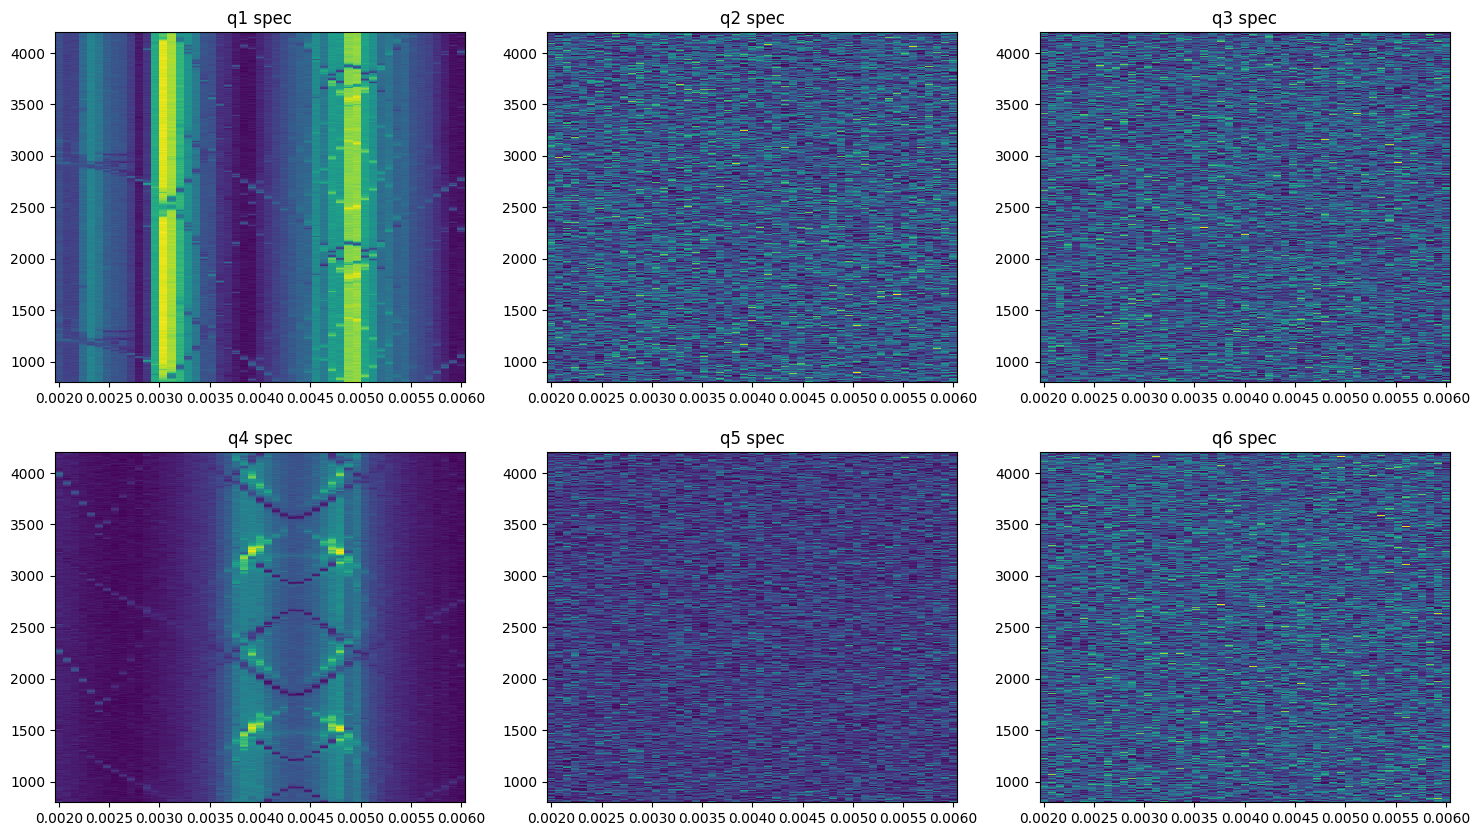

In [836]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freqs = [[]]*6
for idx in range(6):
    freqs[idx]= qspec.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)
axes = axes.flatten()
q_fit=[[]]*6
for i in range(6):
    axes[i].set_title(f'q{i+1} spec')
    axes[i].pcolormesh(flux, freqs[i], np.abs(iqlist[:,i,0].dot([1,1j])).T)

In [837]:
data_path = data_path
for i in range(6):
        exp_name = f"qubit{i} flux spec"


        file_path = get_next_filename_labber(data_path, exp_name)

        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': freqs[i]*1e6},  
                y_info={'name': 'Flux', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values':  np.array(iqlist)[:, i, 0].dot([1, 1j])},
                        
                comment=f'',
                tag='TwoTone mux'
        )


# Rabi

## PowerRabi

In [808]:
class MuxpowerRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        qb_ch = cfg['qb_ch']

        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)
        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)

        ## pulse definition ##
        self.add_loop("gloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )

        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            if i==0:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['q_gain'],
                            length = 0.6
                            )
             
            else:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= 0,
                            gain=cfg['q_gain'],
                            )

    def _body(self, cfg):
        if self.cfg['protocal']=='pi':
            for i in range(6):
                self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        elif self.cfg['protocal']=='pipi':
            for i in range(6):
                self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)
            self.delay_auto(t=0.0) 
            for i in range(6):
                self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)
        self.delay_auto(t=0.01, tag='waiting') 
        self.pulse(ch=cfg['res_ch'], name="mymux", t = 0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'])

config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 1, 1, 1],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.73,
          'res_len': 1,
          'ro_len': 1,
         }


step = 50

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50, 4612.60-0.12-0.29, 4574.18-0.15+0.6, 4182.58-0.09+0.21],
    'qmixer_freq': 4300,
    'q_gain': QickSweep1D("gloop", 0, 1),
    'sigma':0.018,
    'protocal':'pi'
}

run_cfg = {**config, **qb_cfg}

In [ ]:
prog = MuxpowerRabi(soccfg, reps=100, final_delay=100, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=50)
gains = prog.get_pulse_param('qb1_pulse', 'gain', as_array=True)

100%|██████████| 10/10 [00:05<00:00,  1.86it/s]


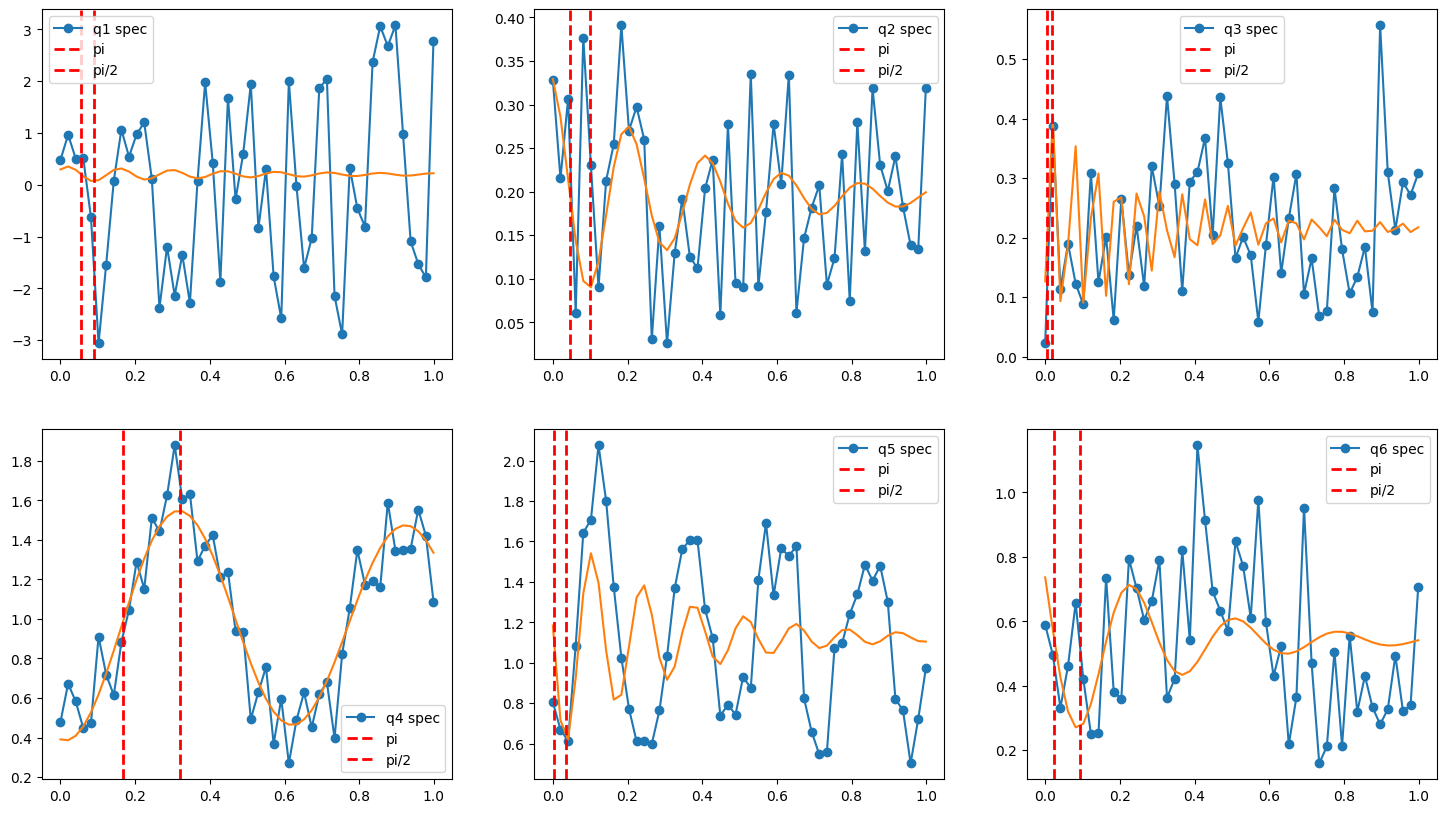

In [812]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
prabi_fit=[[]]*6
for i in range(6):
    if i==0:
        axes[i].plot(gains, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} spec')
    else:
        axes[i].plot(gains, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} spec')
    pOpt, _ = fitdecaysin(gains,  np.abs(iq_list[i][0].dot([1,1j]))) 
    axes[i].plot(gains, decaysin(gains, *pOpt))
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[i].axvline(pi_gain, ls='--', lw=2, color='r', label='pi')
    axes[i].axvline(pi2_gain, ls='--', lw=2, color='r', label='pi/2')
    axes[i].legend()
    prabi_fit[i]=([round(pi_gain,3), round(pi2_gain,3)])


100%|██████████| 100/100 [00:38<00:00,  2.60it/s]


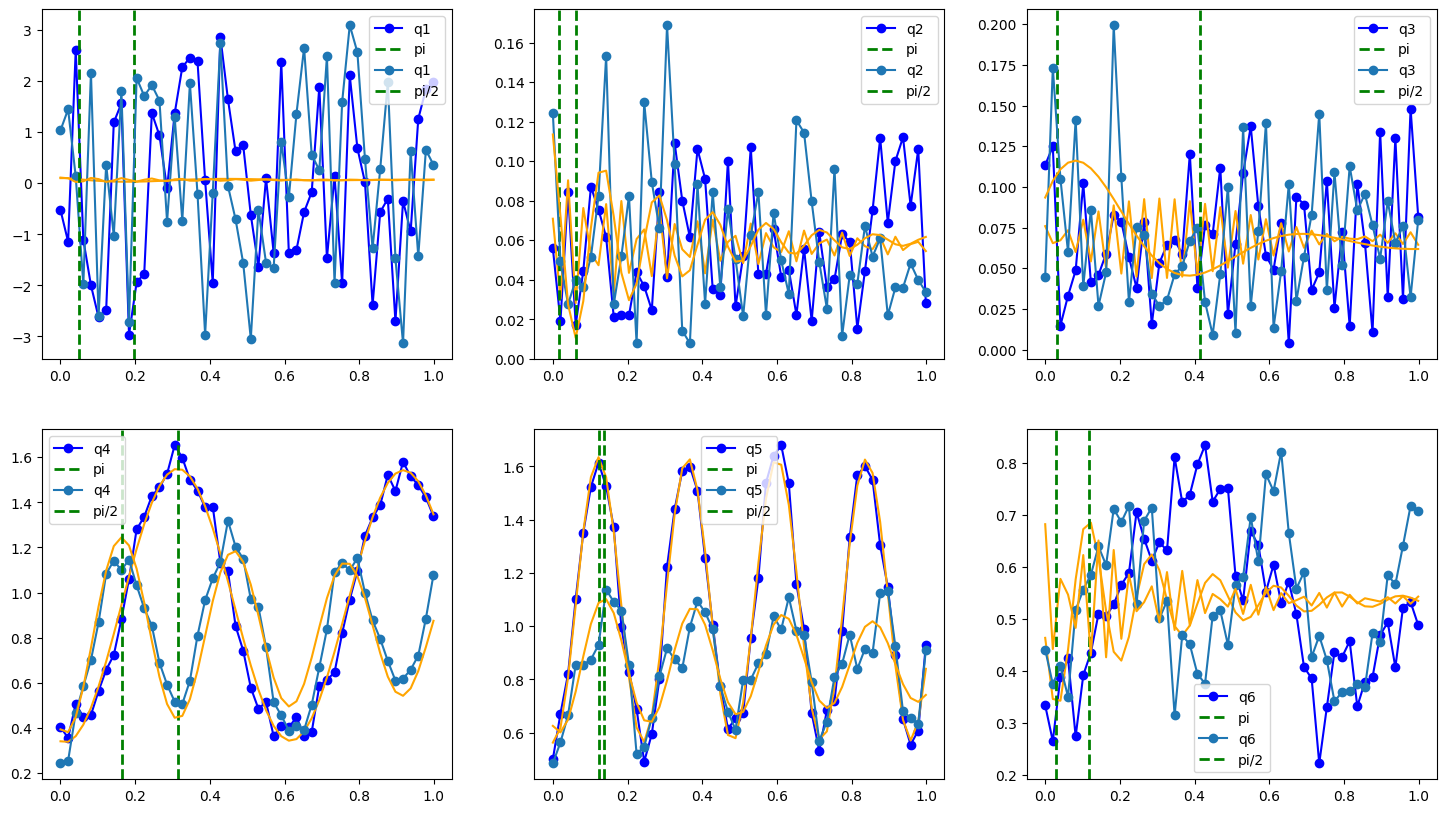

In [813]:
py_avg = 100
run_cfg['protocal']='pi'
prog = MuxpowerRabi(soccfg, reps=100, final_delay=70, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=py_avg)
gains = prog.get_pulse_param('qb1_pulse', 'gain', as_array=True)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

prabi_fit=[[[],[]]]*6

for i in range(6):
    if i==0:
        axes[i].plot(gains, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1}', color='b')
    else:
        axes[i].plot(gains, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1}', color='b')
    pOpt, _ = fitdecaysin(gains,  np.abs(iq_list[i][0].dot([1,1j]))) 
    axes[i].plot(gains, decaysin(gains, *pOpt), color='orange')
    pi_gain, _ = pipulse_analyze(pOpt)
    axes[i].axvline(pi_gain, ls='--', lw=2, color='g', label='pi')
    axes[i].legend()
    prabi_fit[i][0]=(round(pi_gain,3))
##################################### pipi  ####################################################
run_cfg['protocal']='pipi'
prog = MuxpowerRabi(soccfg, reps=100, final_delay=70, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=py_avg)
gains = prog.get_pulse_param('qb1_pulse', 'gain', as_array=True)
for i in range(6):
    if i==0:
        axes[i].plot(gains, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1}')
    else:
        axes[i].plot(gains, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1}')
    pOpt, _ = fitdecaysin(gains,  np.abs(iq_list[i][0].dot([1,1j]))) 
    axes[i].plot(gains, decaysin(gains, *pOpt), color='orange')
    pi_gain, _ = pipulse_analyze(pOpt)
    axes[i].axvline(pi_gain, ls='--', lw=2, color='g', label='pi/2')
    axes[i].legend()
    prabi_fit[i][1]=(round(pi_gain,3))

# Ramsey

In [ ]:
class MuxT2r(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        qb_ch = cfg['qb_ch']
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)

        ## pulse definition ##
        self.add_pulse(ch=res_ch, name="mymux", 
                style="const", 
                length=cfg["res_len"],
                mask=[0,1,2,3,4,5],
                )
                
        self.add_loop("waitloop", cfg["steps"])
        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            if i==0:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['pi_pulse'][i][1],
                            length=0.5
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase=cfg['wait_time']*360*cfg['ramsey_freq'],
                            gain=cfg['pi_pulse'][i][1],
                            length=0.5
                            )
            else:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= 0,
                            gain=cfg['pi_pulse'][i][1],
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                            gain=cfg['pi_pulse'][i][1],
                            )


    def _body(self, cfg):
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
        self.delay_auto(cfg['wait_time']+0.01, tag='wait') 
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)            

        # for i in self.cfg['open_ch']:
        #     self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
        # self.delay_auto(cfg['wait_time']+0.01, tag='wait') 
        # for i in self.cfg['open_ch']:
        #     self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)
            
        self.delay_auto(0.01, tag='allign') 
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 1, 1, 1],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.73,
          'res_len': 1,
          'ro_len': 1,
         }


step = 50
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50, 4612.60-0.12-0.29, 4574.18-0.15+0.6, 4182.58-0.09+0.21],
    'qmixer_freq': 4300,
    'wait_time': QickSweep1D('waitloop', 0.05, 2), # [us]
    'sigma':0.018,
    'pi_pulse':prabi_fit,
    'ramsey_freq': 2,
    'relax_delay': 50, 
}

run_cfg = {**config, **qb_cfg}

In [806]:
pyavg = 50
t2r=MuxT2r(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = t2r.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times = t2r.get_time_param('wait', "t", as_array=True)

100%|██████████| 50/50 [00:14<00:00,  3.51it/s]


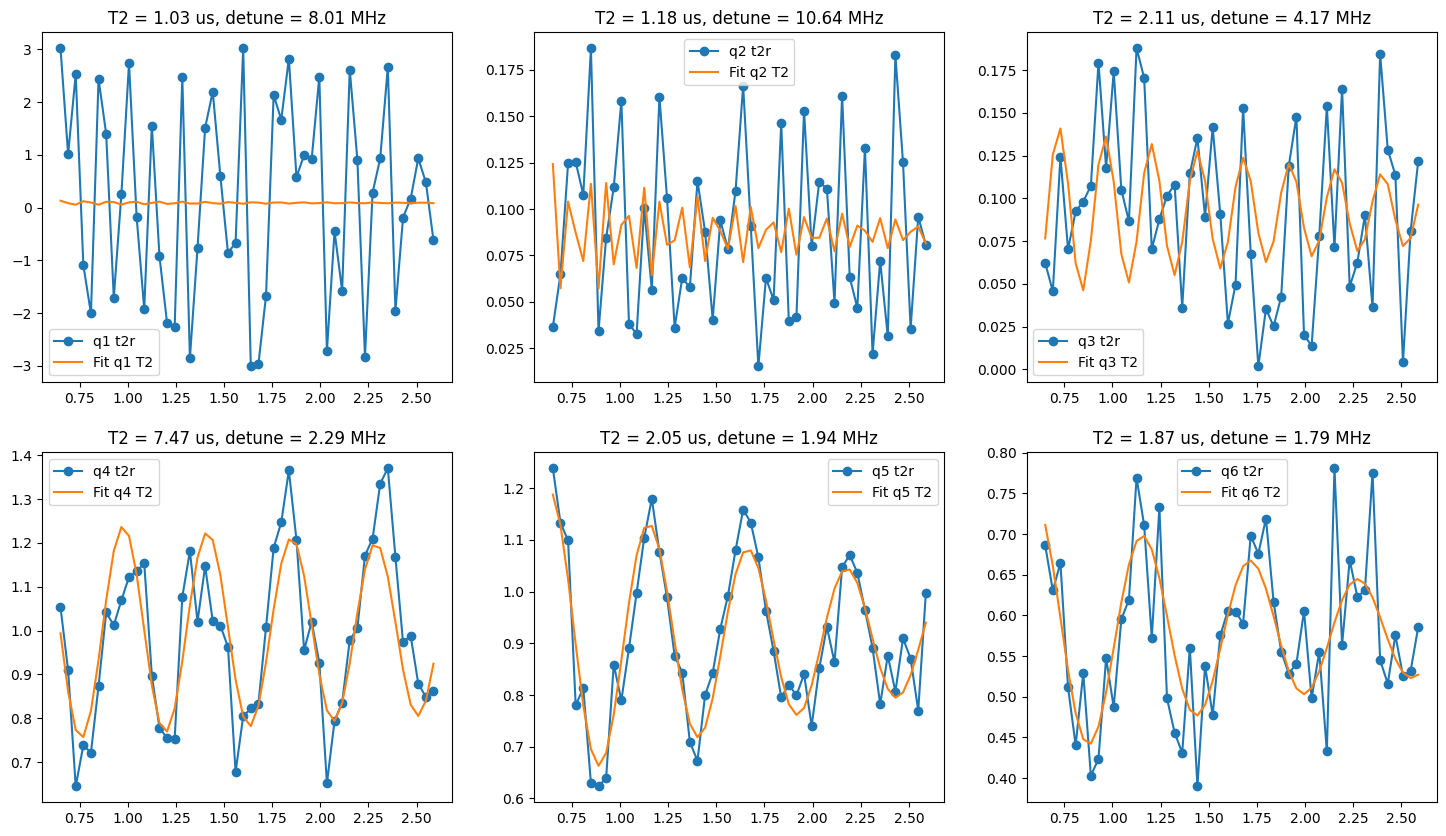

In [807]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
t2r_fit=[[]]*6

for i in range(6):
    if i==0:
        axes[i].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    else:
        axes[i].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    pOpt, _ = fitdecaysin(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[i].plot(delay_times, decaysin(delay_times, *pOpt), label=f'Fit q{i+1} T2')
    axes[i].set_title(f'T2 = {pOpt[3]:.2f} us, detune = {pOpt[1]:.2f} MHz')
    axes[i].legend()
    # if round(pOpt[1],2)/abs(qb_cfg['ramsey_freq'])>0.7:
    #     run_cfg['f_q'][i] = qb_cfg['f_q'][i] - (round(pOpt[1],2)-qb_cfg['ramsey_freq'])
    # else:
    #     pass
    t2r_fit[i] = [round(pOpt[3],3), round(pOpt[1],3)]


## check zz

Attempted to init fitparam 1 to 17.724509090909102, which is out of bounds 0.026240390482001223 to 7.872117144600367. Instead init to 3.949178767541184


100%|██████████| 200/200 [02:45<00:00,  1.21it/s]


Attempted to init fitparam 1 to 17.985163636363648, which is out of bounds 0.026240390482001223 to 7.872117144600367. Instead init to 3.949178767541184


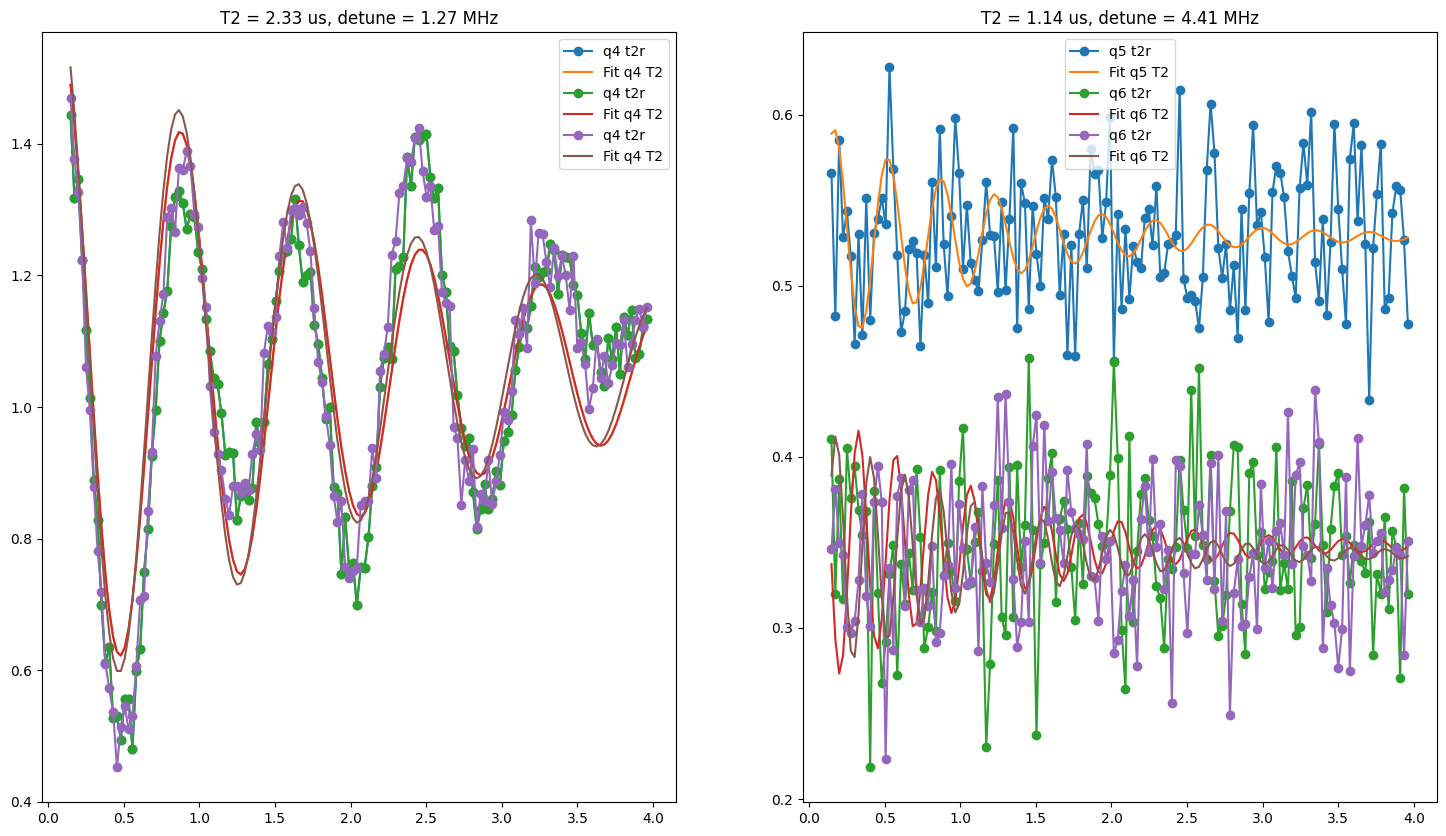

In [765]:
run_cfg['open_ch'] = [3,5]
pyavg = 200
t2r=MuxT2r(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
delay_times = t2r.get_time_param('wait', "t", as_array=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
axes = axes.flatten()
zz=[]
zz_46=[]
zz_45=[]

for idx, i in enumerate([3,4]):
    if i==0:
        axes[idx].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    else:
        axes[idx].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    pOpt, _ = fitdecaysin(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[idx].plot(delay_times, decaysin(delay_times, *pOpt), label=f'Fit q{i+1} T2')
    axes[idx].set_title(f'T2 = {pOpt[3]:.2f} us, detune = {pOpt[1]:.2f} MHz')
    axes[idx].legend()
    zz_45.append(pOpt[1])


for idx, i in enumerate([3,5]):
    if i==0:
        axes[idx].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    else:
        axes[idx].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    pOpt, _ = fitdecaysin(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[idx].plot(delay_times, decaysin(delay_times, *pOpt), label=f'Fit q{i+1} T2')
    axes[idx].set_title(f'T2 = {pOpt[3]:.2f} us, detune = {pOpt[1]:.2f} MHz')
    axes[idx].legend()
    zz_46.append(pOpt[1])


run_cfg['open_ch'] = [3]
t2r=MuxT2r(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = t2r.acquire(soc, soft_avgs=pyavg, progress=True)
for idx, i in enumerate([3,5]):
    if i==0:
        axes[idx].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    else:
        axes[idx].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2r')
    pOpt, _ = fitdecaysin(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[idx].plot(delay_times, decaysin(delay_times, *pOpt), label=f'Fit q{i+1} T2')
    axes[idx].set_title(f'T2 = {pOpt[3]:.2f} us, detune = {pOpt[1]:.2f} MHz')
    axes[idx].legend()
    zz.append(pOpt[1])

In [814]:
print(zz[0])
print(zz_45[0])
print(zz_46[0])

1.267902097412938
1.2581293233806972
1.2581293233806972


# Spin Echo

In [ ]:
class MuxT2e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        qb_ch = cfg['qb_ch']
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)

        ## pulse definition ##
        self.add_pulse(ch=res_ch, name="mymux", 
                style="const", 
                length=cfg["res_len"],
                mask=[0,1,2,3,4,5],
                )
                
        self.add_loop("waitloop", cfg["steps"])
        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            if i==0:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['pi_pulse'][i][0],
                            length=0.5
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['pi_pulse'][i][1],
                            length=0.5
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase=cfg['wait_time']*360*cfg['ramsey_freq'],
                            gain=cfg['pi_pulse'][i][1],
                            length=0.5
                            )
            else:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['pi_pulse'][i][0],
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= 0,
                            gain=cfg['pi_pulse'][i][1],
                            )
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                            gain=cfg['pi_pulse'][i][1],
                            )


    def _body(self, cfg):
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
        self.delay_auto(cfg['wait_time']/2+0.01, tag='wait1') 
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time']/2+0.01, tag='wait2') 
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)
            
        self.delay_auto(0.01, tag='allign') 
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 0.5, 0.5, 0.5],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 2,
          'ro_len': 2,
         }


step = 50
np.array(q_fit)[:,2] =[1313.95,4285.81,4016.50,4612.60,4574.18,4182.58]
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50,4612.60,4574.18,4182.58],
    'qmixer_freq': 4300,
    'wait_time': QickSweep1D('waitloop', 0.05, 6), # [us]
    'sigma':0.016,
    'pi_pulse':prabi_fit,
    'ramsey_freq': 2,
    'relax_delay': 50, 
}

run_cfg = {**config, **qb_cfg}

In [641]:
pyavg = 100
t2e=MuxT2e(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = t2e.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times1 = t2e.get_time_param('wait1', "t", as_array=True)
delay_times2 = t2e.get_time_param('wait2', "t", as_array=True)

100%|██████████| 100/100 [00:30<00:00,  3.27it/s]


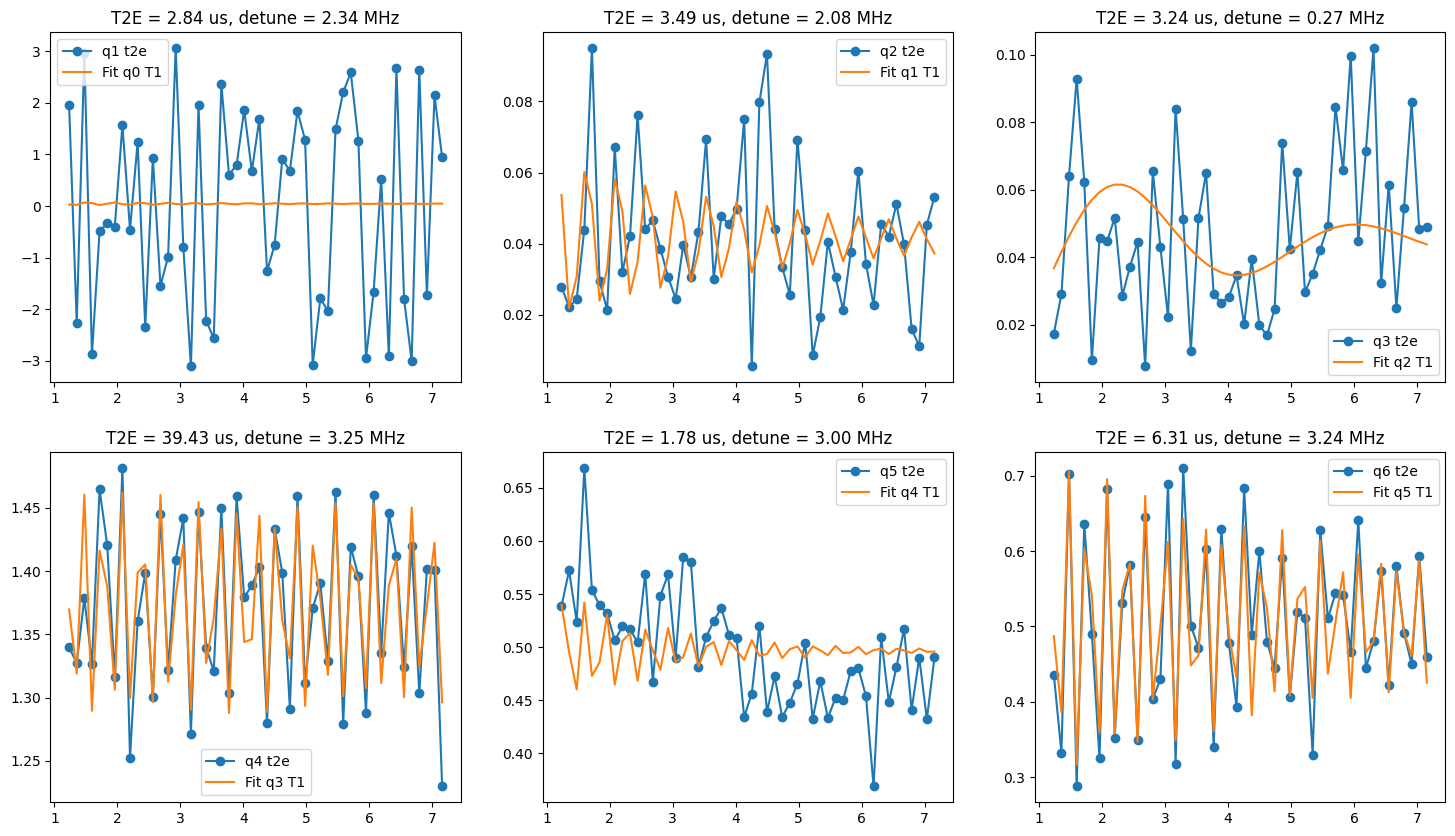

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
t2e_fit=[[]]*6
delay_times = delay_times1 + delay_times2
for i in range(6):
    if i==0:
        axes[i].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2e')
    else:
        axes[i].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t2e')
    pOpt, _ = fitdecaysin(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[i].plot(delay_times, decaysin(delay_times, *pOpt), label=f'Fit q{i} T1')
    axes[i].set_title(f'T2E = {pOpt[3]:.2f} us, detune = {pOpt[1]:.2f} MHz')
    axes[i].legend()
    t2e_fit[i] = [round(pOpt[3],3), round(pOpt[1],3)]


# T1

In [785]:
class MuxT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        qb_ch = cfg['qb_ch']
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)

        ## pulse definition ##
        self.add_pulse(ch=res_ch, name="mymux", 
                style="const", 
                length=cfg["res_len"],
                mask=[0,1,2,3,4,5],
                )
                
        self.add_loop("waitloop", cfg["steps"])
        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            if i==0:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                            style="flat_top",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i], 
                            phase= 0,
                            gain=cfg['pi_pulse'][i][0],
                            length=0.5
                            )
            else:
                self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                            style="arb",  
                            envelope=f'ramp{i}',                   
                            freq=cfg['f_q'][i],                        
                            phase= 0,
                            gain=cfg['pi_pulse'][i][0],
                            )

    def _body(self, cfg):
        for i in range(6):
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time']+0.01, tag='wait') # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 1, 1, 1],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 2,
          'ro_len': 2,
         }


step = 50
np.array(q_fit)[:,2] =[1313.95,4285.81,4016.50,4612.60,4574.18,4182.58]
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50, 4612.60-0.12, 4574.18-0.15, 4182.58-0.09],
    'qmixer_freq': 4300,
    'wait_time': QickSweep1D('waitloop', 0.05, 50), # [us]
    'sigma':0.018,
    'pi_pulse':prabi_fit,
    'ramsey_freq': 2,
    'relax_delay': 50, 
}

run_cfg = {**config, **qb_cfg}

In [786]:
pyavg = 100
T1=MuxT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

100%|██████████| 100/100 [00:41<00:00,  2.44it/s]


c:\Users\QEL\Anaconda3\envs\qick\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
c:\Users\QEL\Desktop\tprocv2_guidemo-main\csutscrip\data_fitting\fitting.py:99: RuntimeWarning: overflow encountered in exp
  return y0 + yscale * np.exp(-(x - x0) / decay)


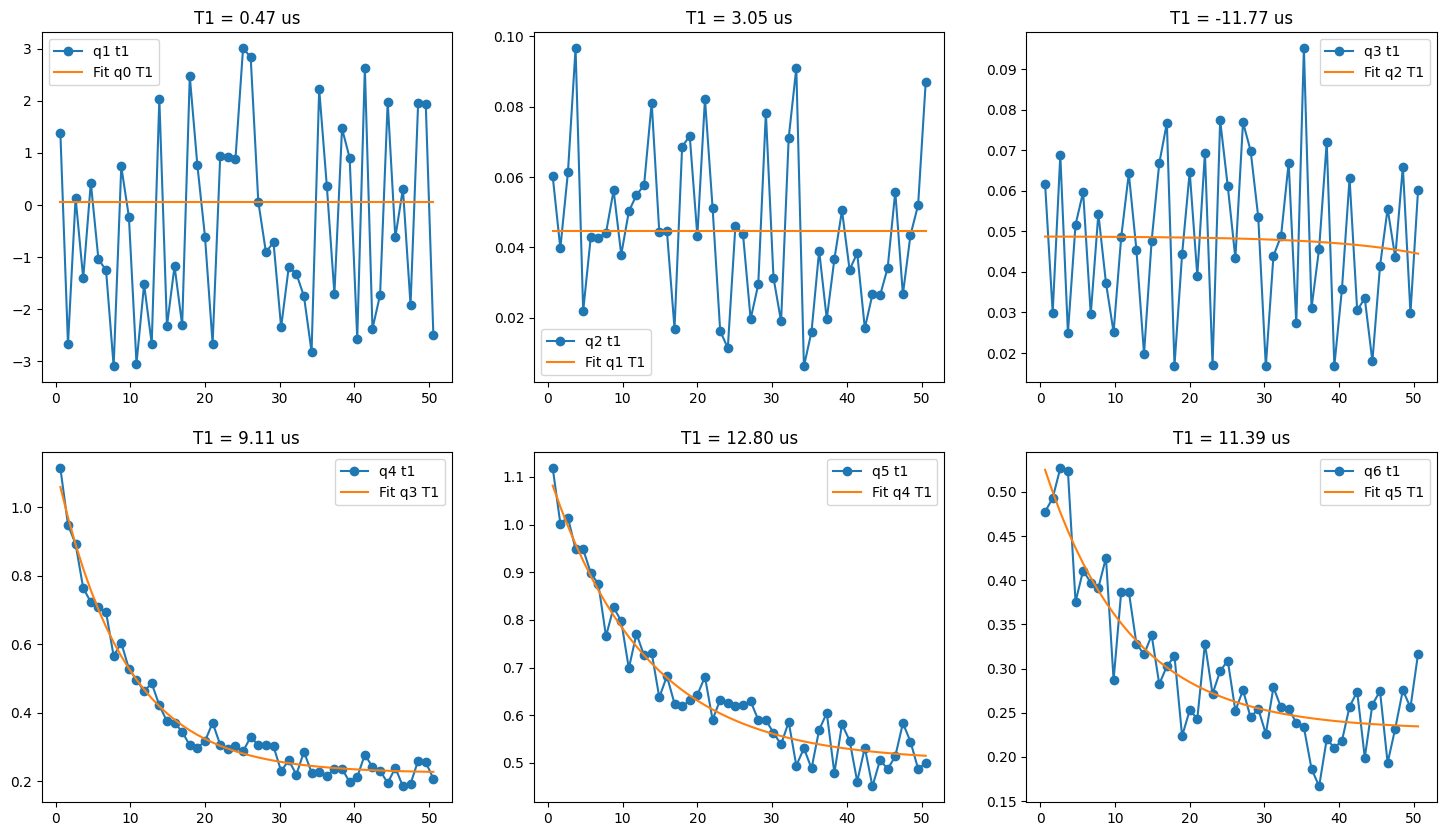

In [787]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
t1_fit=[[]]*6

for i in range(6):
    if i==0:
        axes[i].plot(delay_times, np.angle(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t1')
    else:
        axes[i].plot(delay_times, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t1')
    pOpt, _ = fitexp(delay_times,  np.abs(iq_list[i][0].dot([1,1j])))
    axes[i].plot(delay_times, expfunc(delay_times, *pOpt), label=f'Fit q{i} T1')
    axes[i].set_title(f'T1 = {pOpt[3]:.2f} us')
    axes[i].legend()
    t1_fit[i] = round(pOpt[3],3)


In [654]:
t2r_fit[5]

[6.31, 3.238]

# monitor

In [736]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 1, 1, 1],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.73,
          'res_len': 1,
          'ro_len': 1,
         }

step = 100

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50, 4612.60-0.12, 4574.18-0.15, 4182.58-0.09],
    'qmixer_freq': 4300,
    'wait_time': QickSweep1D('waitloop', 0.05, 2), # [us]
    'sigma':0.018,
    'pi_pulse':prabi_fit,
    'ramsey_freq': 2,
    'relax_delay': 50, 
}

run_cfg = {**config, **qb_cfg}

In [ ]:
# run_cfg['wait_time'] =  QickSweep1D('waitloop', 0.05, 2)
# t2r=MuxT2r(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
# t2iq_list = t2r.acquire(soc, soft_avgs=pyavg, progress=True)
# delay_times = t2r.get_time_param('wait', "t", as_array=True)

In [737]:
run_cfg['wait_time'] =  QickSweep1D('waitloop', 0.05, 40)
T1=MuxT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
t1iq_list = T1.acquire(soc, soft_avgs=50, progress=True)
delay_times = T1.get_time_param('wait', "t", as_array=True)

100%|██████████| 50/50 [00:36<00:00,  1.35it/s]


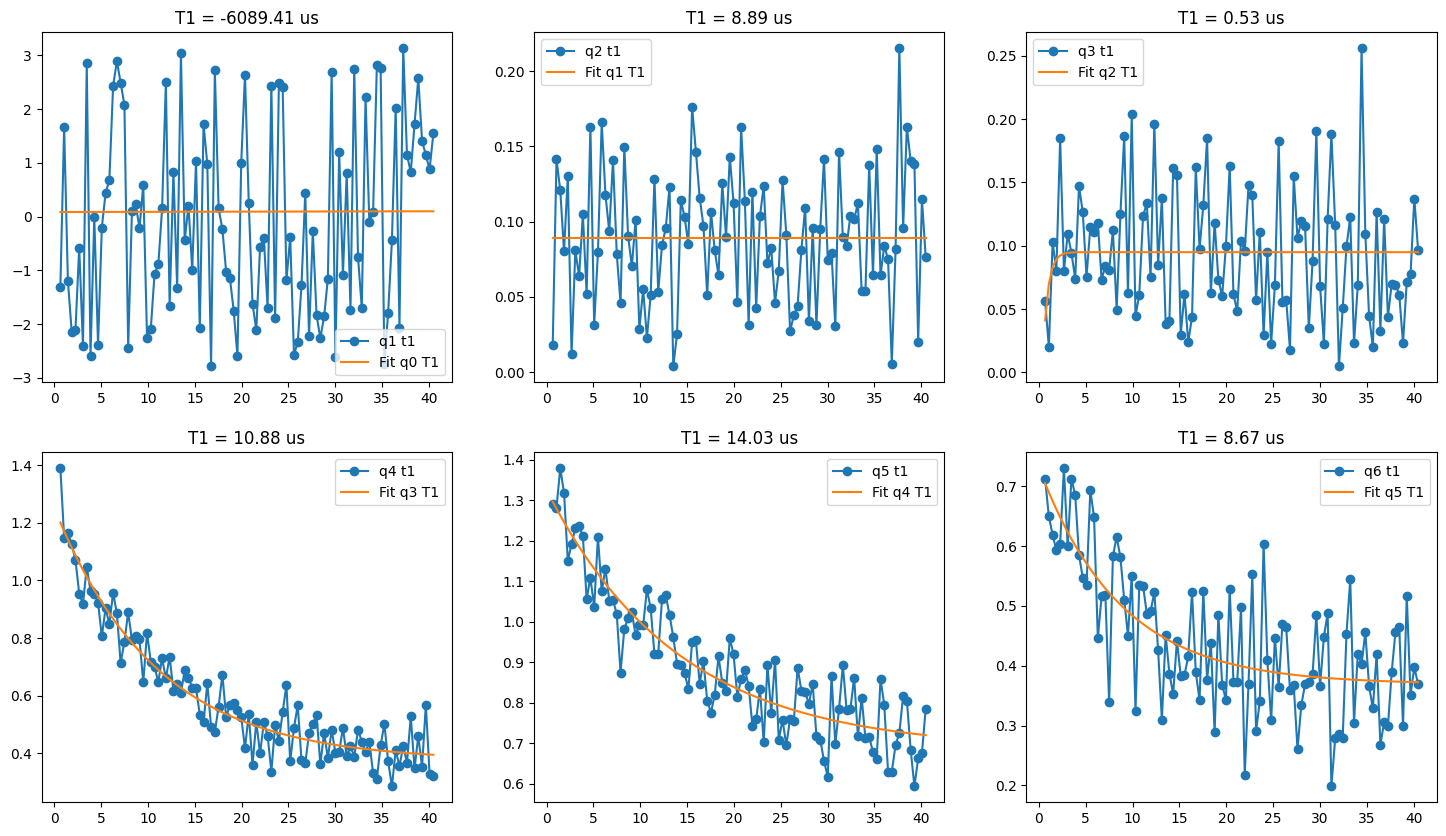

In [740]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
t1_fit=[[]]*6

for i in range(6):
    if i==0:
        axes[i].plot(delay_times, np.angle(t1iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t1')
    else:
        axes[i].plot(delay_times, np.abs(t1iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} t1')
    pOpt, _ = fitexp(delay_times,  np.abs(t1iq_list[i][0].dot([1,1j])))
    axes[i].plot(delay_times, expfunc(delay_times, *pOpt), label=f'Fit q{i} T1')
    axes[i].set_title(f'T1 = {pOpt[3]:.2f} us')
    axes[i].legend()
    # t1_fit[i] = round(pOpt[3],3)

In [742]:
import time
from datetime import datetime
import os
import pandas as pd
import numpy as np

pyavg = 200


filename = "q456_monitor_log.csv"

if not os.path.exists(filename):
    with open(filename, "w") as f:
        f.write("timestamp,q4_T1,q5_T1,q6_T1,q4_T2,q5_T2,q6_T2,q4_detune,q5_detune,q6_detune\n")

try:
    while True:
        now = datetime.now()
        print(f"Measurement at {now.strftime('%Y-%m-%d %H:%M:%S')}")

        run_cfg['wait_time'] = QickSweep1D('waitloop', 0.05, 3)
        t2r = MuxT2r(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        t2iq_list = t2r.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times_t2 = t2r.get_time_param('wait', "t", as_array=True)
        t2r_fit = [[]] * 6
        t2r_detune_fit = [[]] * 6
        for i in range(6):
            t2popt, _ = fitdecaysin(delay_times_t2, np.abs(t2iq_list[i][0].dot([1, 1j])))
            t2r_fit[i] = round(t2popt[3], 3)
            t2r_detune_fit[i] = round(t2popt[1], 3) - 2

        run_cfg['wait_time'] = QickSweep1D('waitloop', 0.05, 50)
        T1 = MuxT1(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        t1iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times_t1 = T1.get_time_param('wait', "t", as_array=True)
        t1_fit = [[]] * 6
        for i in range(6):
            t1popt, _ = fitexp(delay_times_t1, np.abs(t1iq_list[i][0].dot([1, 1j])))
            t1_fit[i] = round(t1popt[3], 3)

        with open(filename, "a") as f:
            f.write(
                f"{now}," +
                ",".join(map(str, t1_fit[3:6])) + "," +
                ",".join(map(str, t2r_fit[3:6])) + "," +
                ",".join(map(str, t2r_detune_fit[3:6])) + "\n"
            )


except KeyboardInterrupt:
    print("\n手動中斷量測，資料已保留。")


Measurement at 2025-04-23 07:56:48
Measurement at 2025-04-23 08:01:17
Attempted to init fitparam 1 to 17.20320000000001, which is out of bounds 0.03620202020202021 to 10.860606060606061. Instead init to 5.448404040404041
Measurement at 2025-04-23 08:05:46
Attempted to init fitparam 1 to 12.185600000000008, which is out of bounds 0.03620202020202021 to 10.860606060606061. Instead init to 5.448404040404041
Attempted to init fitparam 1 to 11.468800000000007, which is out of bounds 0.03620202020202021 to 10.860606060606061. Instead init to 5.448404040404041
Measurement at 2025-04-23 08:10:15
Measurement at 2025-04-23 08:14:45
Attempted to init fitparam 1 to 15.76960000000001, which is out of bounds 0.03620202020202021 to 10.860606060606061. Instead init to 5.448404040404041
Attempted to init fitparam 1 to 15.76960000000001, which is out of bounds 0.03620202020202021 to 10.860606060606061. Instead init to 5.448404040404041
Measurement at 2025-04-23 08:19:14
Attempted to init fitparam 1 to 1

# Allxy

In [788]:
class MuxAllxy(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        qb_ch = cfg['qb_ch']
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        for i in range(6):
            qb_ch[i] = cfg['qb_ch'][i]
            if i==0:
                nqz=1
            else:
                nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)

        ## pulse definition ##
        self.add_pulse(ch=res_ch, name="mymux", 
                style="const", 
                length=cfg["res_len"],
                mask=[0,1,2,3,4,5],
                )
                
        for i in range(6):
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"x180_q{i}", 
                        style="arb", 
                        envelope=f"ramp{i}", 
                        freq=cfg['f_q'][i],
                        phase=0,
                        gain=cfg['pi_pulse'][i][0], 
                        )
            self.add_pulse(ch=qb_ch[i], name=f"x90_q{i}", 
                    style="arb", 
                    envelope=f"ramp{i}", 
                    freq=cfg['f_q'][i], 
                    phase=0,
                    gain=cfg['pi_pulse'][i][1], 
                    )
            self.add_pulse(ch=qb_ch[i], name=f"y180_q{i}", 
                        style="arb", 
                        envelope=f"ramp{i}", 
                        freq=cfg['f_q'][i],
                        phase=90,
                        gain=cfg['pi_pulse'][i][0], 
                        )
            self.add_pulse(ch=qb_ch[i], name=f"y90_q{i}", 
                    style="arb", 
                    envelope=f"ramp{i}", 
                    freq=cfg['f_q'][i], 
                    phase=90,
                    gain=cfg['pi_pulse'][i][1], 
                    )

    def _body(self, cfg):

        if cfg['allxy_gates'][0]=='I':
            pass 
        else:
            for i in range(6):
                self.pulse(ch=cfg['qb_ch'][i], name=f"{self.cfg['allxy_gates'][0]}_q{i}", t=0)
                
        self.delay_auto(0.0) 

        if cfg['allxy_gates'][1]=='I':
            pass 
        else:
            for i in range(6):
                self.pulse(ch=cfg['qb_ch'][i], name=f"{self.cfg['allxy_gates'][1]}_q{i}", t=0)
        

        self.delay_auto(0.01, tag='allign') 
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': res_mixer,
          'res_gains': [0, 0, 0, 1, 1, 1],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.73,
          'res_len': 2,
          'ro_len': 2,
         }


step = 150
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': [1313.95,4285.81,4016.50, 4612.60-0.12, 4574.18-0.15, 4182.58-0.09],
    'qmixer_freq': 4300,
    'sigma':0.018,
    'pi_pulse':prabi_fit,
    'ramsey_freq': 1,
    'relax_delay': 50, 
}

run_cfg = {**config, **qb_cfg}

In [789]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


In [790]:
pyavg = 50

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=MuxAllxy(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, soft_avgs=pyavg, progress=False)
    allxy_lst.append(iq_list)

100%|██████████| 21/21 [00:17<00:00,  1.18it/s]


In [ ]:
np.array(allxy_lst).shape


(21, 6, 1, 2)

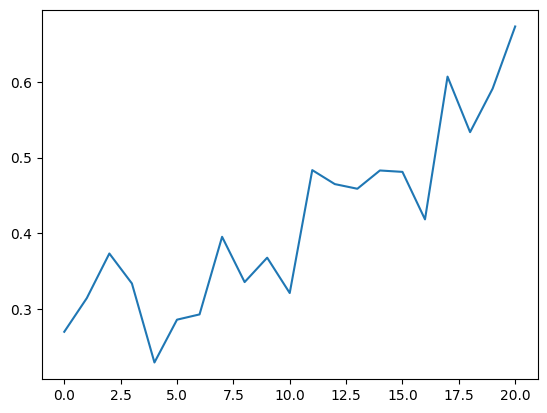

In [800]:
plt.plot(np.abs(np.array(allxy_lst)[:,5,0].dot([1,1j])))